In [1]:
%load_ext autotime

import scarf

scarf.fetch_dataset("tenx_5K_pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True)

ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr", nthreads=4, min_features_per_cell=10
)

time: 29.8 s (started: 2026-07-04 09:41:03 +02:00)


597 cells flagged for filtering out using attribute RNA_nCounts



Calculating summary statistics



Using cached feature stats for cell_key I



Using existing corrected dispersion values



Calculating HVGs



500 genes marked as HVGs



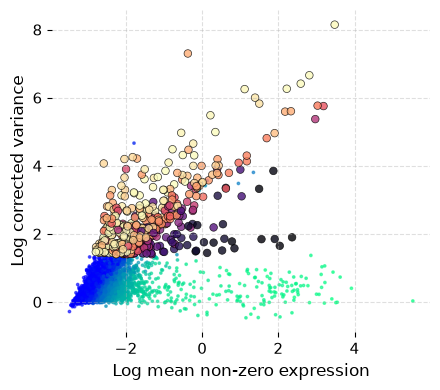

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 1.0s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.1s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 15.4s (7/7 steps, 15.2s in logged steps)



Training UMAP:   0%|                                                                                          …

time: 21.1 s (started: 2026-07-04 09:41:32 +02:00)


In [2]:
ds.filter_cells(attrs=["RNA_nCounts"], highs=[15000], lows=[1000])
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15)
ds.run_umap(n_epochs=200, parallel=True)

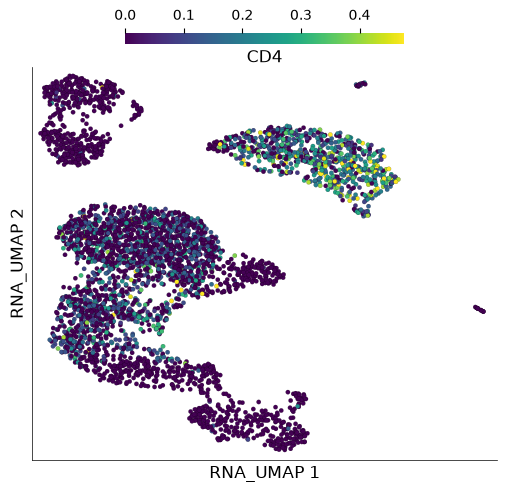

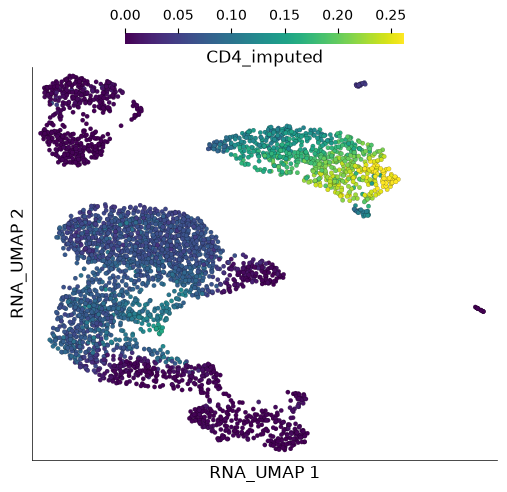

time: 1.34 s (started: 2026-07-04 09:41:52 +02:00)


In [3]:
imputed_cd4 = ds.get_imputed(feature_name="CD4", t=2)

ds.cells.insert("CD4_imputed", imputed_cd4, overwrite=True)

ds.plot_layout(layout_key="RNA_UMAP", color_by="CD4", from_assay="RNA")
ds.plot_layout(layout_key="RNA_UMAP", color_by="CD4_imputed")